<a href="https://colab.research.google.com/github/rb3890-rgb/clmt5405-assignments/blob/main/numpy_and_matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NumPy and Matplotlib

Climate data is, underneath it all, **numbers in arrays** — a grid of model temperatures, a satellite swath, a stack of float profiles. **NumPy** is the library that lets Python store and compute on those arrays efficiently, and **Matplotlib** is how we turn them into figures. Almost everything later in this course (pandas, xarray) is built on top of these two.

In this notebook we'll create and index arrays, do math across whole arrays at once (vectorization and **broadcasting**), reduce them to summary statistics, and make our first plots.

- **NumPy** — *the fundamental package for scientific computing with Python* (numpy.org)
- **Matplotlib** — *a comprehensive library for static, animated, and interactive visualizations* (matplotlib.org)

> **In-class assignment — 10 points.** Each **Try it** prompt below is followed by a `Try it — my attempt` cell containing the solution.

## Importing and Examining a New Package

This will be our first experience with *importing* a package that is not part of the Python standard library.

In [57]:
import numpy as np

We can use `dir()` to see the variables we currently have access to — `np` should now be one of them.

In [58]:
dir()

['In',
 'Out',
 '_',
 '_10',
 '_15',
 '_16',
 '_17',
 '_18',
 '_19',
 '_2',
 '_20',
 '_23',
 '_24',
 '_25',
 '_28',
 '_3',
 '_30',
 '_32',
 '_33',
 '_34',
 '_35',
 '_36',
 '_37',
 '_4',
 '_40',
 '_41',
 '_44',
 '_47',
 '_49',
 '_50',
 '_51',
 '_54',
 '_6',
 '_7',
 '_8',
 '_9',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '_dh',
 '_i',
 '_i1',
 '_i10',
 '_i11',
 '_i12',
 '_i13',
 '_i14',
 '_i15',
 '_i16',
 '_i17',
 '_i18',
 '_i19',
 '_i2',
 '_i20',
 '_i21',
 '_i22',
 '_i23',
 '_i24',
 '_i25',
 '_i26',
 '_i27',
 '_i28',
 '_i29',
 '_i3',
 '_i30',
 '_i31',
 '_i32',
 '_i33',
 '_i34',
 '_i35',
 '_i36',
 '_i37',
 '_i38',
 '_i39',
 '_i4',
 '_i40',
 '_i41',
 '_i42',
 '_i43',
 '_i44',
 '_i45',
 '_i46',
 '_i47',
 '_i48',
 '_i49',
 '_i5',
 '_i50',
 '_i51',
 '_i52',
 '_i53',
 '_i54',
 '_i55',
 '_i56',
 '_i57',
 '_i58',
 '_i6',
 '_i7',
 '_i8',
 '_i9',
 '_ih',
 '_ii',
 '_iii',
 '_oh',
 'a',
 'arr',
 'arr3d',
 'arr3d_loaded',
 'a

NumPy has hundreds of functions and types — `dir(np)` lists them all. A common pattern is to filter that list for names containing a keyword you care about:

In [59]:
[name for name in dir(np) if 'lin' in name]

['linalg', 'linspace']

You can check the version of any package via its `__version__` attribute — useful when reproducing results or filing bug reports:

In [60]:
np.__version__

'2.0.2'

There is no way we could explicitly teach each of these functions. The numpy documentation is crucial!

https://numpy.org/doc/stable/reference/

> **Try it.** Import the `math` module (`import math`). Use `dir(math)` to peek at what's inside. Pick a function that looks interesting (e.g. `log`, `factorial`, `sqrt`) and call `help()` on it to read its signature and docstring.

**Try it — my attempt**

In [61]:
import math

# Peek at what's inside the math module
print(dir(math))

# Read the signature + docstring of a function
help(math.log)

# Try a few out
print(math.factorial(5))   # 120
print(math.sqrt(2))        # 1.41421356...
print(math.log(math.e))    # 1.0

['__doc__', '__loader__', '__name__', '__package__', '__spec__', 'acos', 'acosh', 'asin', 'asinh', 'atan', 'atan2', 'atanh', 'cbrt', 'ceil', 'comb', 'copysign', 'cos', 'cosh', 'degrees', 'dist', 'e', 'erf', 'erfc', 'exp', 'exp2', 'expm1', 'fabs', 'factorial', 'floor', 'fmod', 'frexp', 'fsum', 'gamma', 'gcd', 'hypot', 'inf', 'isclose', 'isfinite', 'isinf', 'isnan', 'isqrt', 'lcm', 'ldexp', 'lgamma', 'log', 'log10', 'log1p', 'log2', 'modf', 'nan', 'nextafter', 'perm', 'pi', 'pow', 'prod', 'radians', 'remainder', 'sin', 'sinh', 'sqrt', 'sumprod', 'tan', 'tanh', 'tau', 'trunc', 'ulp']
Help on built-in function log in module math:

log(...)
    log(x, [base=math.e])
    Return the logarithm of x to the given base.

    If the base is not specified, returns the natural logarithm (base e) of x.

120
1.4142135623730951
1.0


## NDArrays

The core class is the numpy ndarray (n-dimensional array). Compared to a regular Python `list`:

- NumPy arrays can have N dimensions (lists, tuples, etc. are 1D).
- NumPy arrays hold values of a single datatype (e.g. `int`, `float`); `list`s can hold anything.
- NumPy optimizes numerical operations on arrays — NumPy is *fast!*

Let's create a 1D array from a Python list, then inspect its properties.

In [62]:
a = np.array([9, 0, 2, 1, 0])
a

array([9, 0, 2, 1, 0])

In [63]:
a.dtype

dtype('int64')

In [64]:
a.shape

(5,)

The shape is returned as a **tuple**, which means we can index it like any other tuple.

In [65]:
type(a.shape)

tuple

Arrays can also be **multi-dimensional** and have an explicit dtype.

In [66]:
b = np.array([[5, 3, 1, 9], [9, 2, 3, 0]], dtype=np.float64)
b.dtype, b.shape

(dtype('float64'), (2, 4))

> **Note.** The fastest-varying dimension is the **last** dimension; the outer level of the hierarchy is the first dimension. (This is called "C-style" indexing.)

> **Try it.** Create three arrays: a 1D array from `[1, 2, 3, 4, 5]`, a 2D array from `[[1, 2], [3, 4]]`, and a 3D array of your choice. Print the `shape` and `dtype` of each. Then create a 1D array that includes a decimal value (e.g. `[1, 2, 3.5]`) and confirm the dtype is now `float64`.

**Try it — my attempt**

In [67]:
arr_1d = np.array([1, 2, 3, 4, 5])
arr_2d = np.array([[1, 2], [3, 4]])
arr_3d = np.array([[[1, 2], [3, 4]], [[5, 6], [7, 8]]])   # shape (2, 2, 2)

for name, arr in [("1D", arr_1d), ("2D", arr_2d), ("3D", arr_3d)]:
    print(f"{name}: shape={arr.shape}, dtype={arr.dtype}")

# A single decimal promotes the whole array to float64
arr_float = np.array([1, 2, 3.5])
print("with decimal:", arr_float.dtype)   # float64

1D: shape=(5,), dtype=int64
2D: shape=(2, 2), dtype=int64
3D: shape=(2, 2, 2), dtype=int64
with decimal: float64


## Array Creation

There are several ways to build arrays beyond passing a list to `np.array`:

- `np.zeros` / `np.ones` / `np.full` — blank arrays of a given shape.
- `np.arange` / `np.linspace` / `np.logspace` — evenly-spaced values along a range.
- `np.meshgrid` — combine 1D arrays into 2D coordinate grids.

In [68]:
print(np.zeros(5))
print(np.ones((2, 3)))
print(np.full((2, 2), 7))
print(np.arange(0, 10, 2))
print(np.linspace(0, 1, 5))

[0. 0. 0. 0. 0.]
[[1. 1. 1.]
 [1. 1. 1.]]
[[7 7]
 [7 7]]
[0 2 4 6 8]
[0.   0.25 0.5  0.75 1.  ]


`meshgrid` creates 2D arrays out of a combination of 1D arrays — it tiles the 1D arrays to a combined shape.

In [69]:
x = np.linspace(-2*np.pi, 2*np.pi, 100)
y = np.linspace(-np.pi, np.pi, 50)
xx, yy = np.meshgrid(x, y)
print(x.shape, y.shape)
print(xx.shape, yy.shape)

(100,) (50,)
(50, 100) (50, 100)


> **Try it.** Use `np.linspace` to create 100 evenly-spaced values between 0 and 1, and `np.arange` to create the integers from 0 to 10. Print the `dtype` and `shape` of each. Then use `np.meshgrid` to build a 2D grid from these two arrays and print its shape.

**Try it — my attempt**

In [70]:
lin  = np.linspace(0, 1, 100)   # 100 evenly-spaced values in [0, 1]
ints = np.arange(0, 11)         # integers 0..10 (stop is exclusive, so 11)

print("linspace:", lin.shape, lin.dtype)    # (100,) float64
print("arange:  ", ints.shape, ints.dtype)  # (11,)  int64

gx, gy = np.meshgrid(lin, ints)
print("meshgrid:", gx.shape)   # (11, 100)

linspace: (100,) float64
arange:   (11,) int64
meshgrid: (11, 100)


## Indexing

Basic indexing is similar to lists — single brackets, zero-based, negative indices count from the end. The key extension is that for N-dimensional arrays you separate the index for each dimension with a comma. Slicing and boolean masks also work.

In [71]:
y[10], y[1:5], y[-5]

(np.float64(-1.8593099378388573),
 array([-3.01336438, -2.88513611, -2.75690784, -2.62867957]),
 np.float64(2.628679567289418))

For multi-dimensional arrays, use a comma to separate the index for each dimension.

In [72]:
xx[0, 0], xx[-1, -1], xx[3, -5]

(np.float64(-6.283185307179586),
 np.float64(6.283185307179586),
 np.float64(5.775453161144872))

Slicing returns whole rows or columns.

In [73]:
xx[0].shape, xx[:, -1].shape

((100,), (50,))

You can take **ranges** across multiple dimensions.

In [74]:
xx[3:10, 30:40].shape

(7, 10)

Boolean indexing is one of many advanced ways to index arrays.

In [75]:
idx = xx < 0
xx[idx].shape

(2500,)

Note that a boolean index always returns a **flat (1D) array**, regardless of the input shape. The `ravel` method does the same flattening explicitly.

In [76]:
xx.ravel().shape

(5000,)

> **Try it.** Take `xx` from the cells above. Get its first row, its last column, and a central 3×3 block via slicing. Then use a **boolean mask** to extract all values of `xx` that are greater than zero — what's the shape of the result?

**Try it — my attempt**

In [77]:
first_row  = xx[0]              # first row
last_col   = xx[:, -1]          # last column
center_3x3 = xx[23:26, 48:51]   # central 3x3 block (xx is 50x100)

print("first row: ", first_row.shape)    # (100,)
print("last col:  ", last_col.shape)     # (50,)
print("center 3x3:", center_3x3.shape)   # (3, 3)

# Boolean mask -> always a flat 1D array
positive = xx[xx > 0]
print("positive values:", positive.shape)

first row:  (100,)
last col:   (50,)
center 3x3: (3, 3)
positive values: (2500,)


## Visualizing Arrays with Matplotlib

It can be hard to work with big arrays without seeing them! We bring in Matplotlib to visualize them.

In [78]:
from matplotlib import pyplot as plt

For plotting a 1D array as a line, we use the `plot` command.

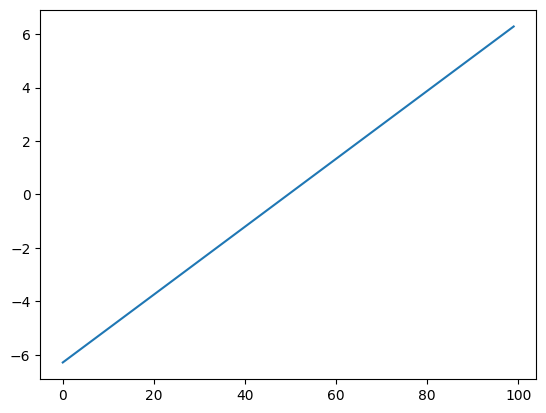

In [79]:
plt.plot(x)

There are many ways to visualize 2D data. Here we use `pcolormesh`.

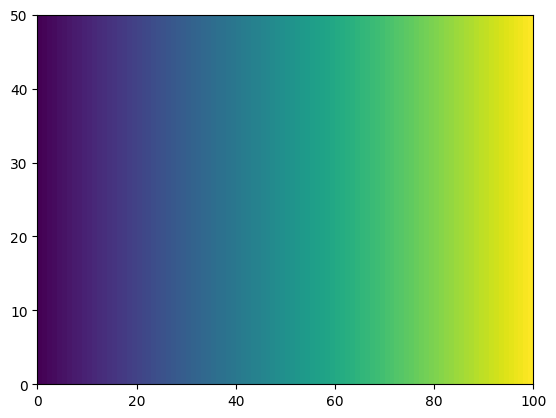

In [80]:
plt.pcolormesh(xx)

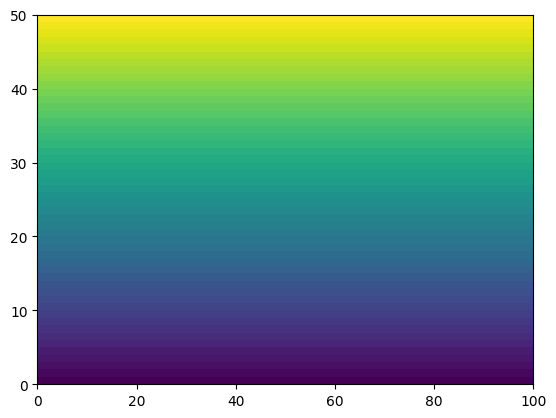

In [81]:
plt.pcolormesh(yy)

> **Try it.** Use `plt.plot` to plot `np.cos(x)` against `x`. Then use `plt.pcolormesh` to visualize the 2D array `xx + yy`.

**Try it — my attempt**

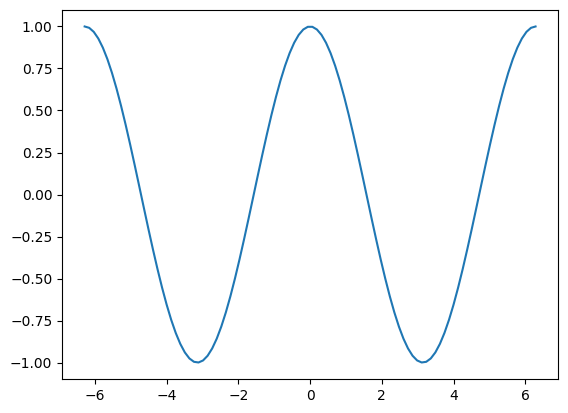

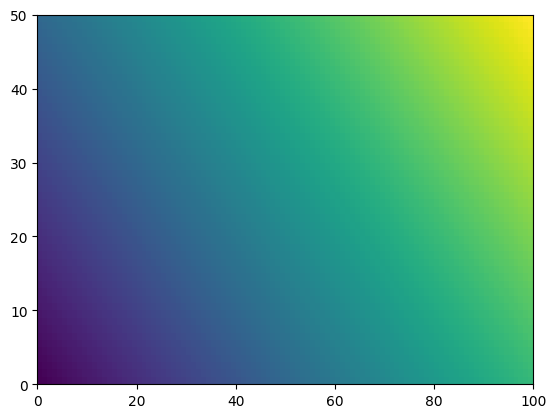

In [82]:
plt.plot(x, np.cos(x))
plt.show()

plt.pcolormesh(xx + yy)
plt.show()

## Array Operations

There are a huge number of operations available on arrays. All the familiar arithmetic operators are applied element-by-element.

### Basic Math

In [83]:
f = np.sin(x)

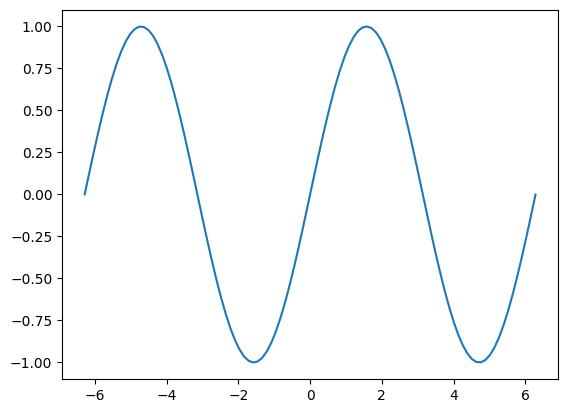

In [84]:
plt.plot(x, f)

Now let's compute a function of two variables — a 2D surface. We use the 2D `xx`/`yy` arrays so the function is evaluated at every grid point.

In [85]:
f = np.sin(xx) * np.cos(0.5 * yy)

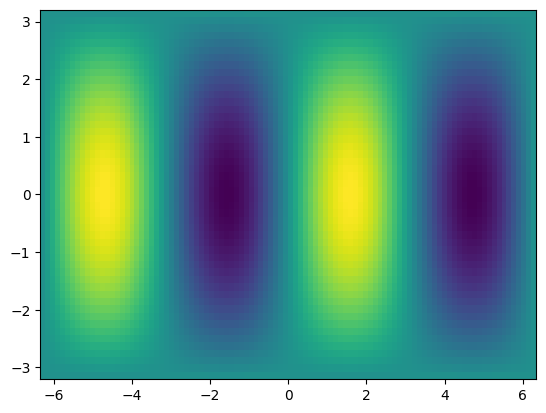

In [86]:
plt.pcolormesh(xx, yy, f)

> **Try it.** Compute a 2D Gaussian on the `xx`/`yy` grid: `gaussian = np.exp(-(xx**2 + yy**2))`. Visualize it with `plt.pcolormesh`. Where is the array largest, and where is it smallest?

**Try it — my attempt**

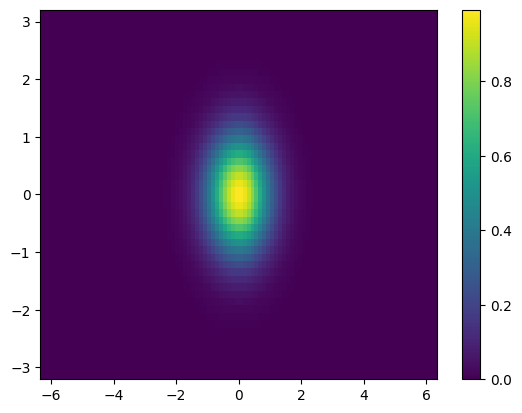

max: 0.9918944075675892 at index (np.int64(24), np.int64(49))
min: 3.701914211848913e-22


In [87]:
gaussian = np.exp(-(xx**2 + yy**2))
plt.pcolormesh(xx, yy, gaussian)
plt.colorbar()
plt.show()

# Largest at the center (0, 0) where the exponent is 0 -> exp(0) = 1.
# Smallest in the far corners where xx**2 + yy**2 is largest -> exp(-big) ~ 0.
print("max:", gaussian.max(),
      "at index", np.unravel_index(gaussian.argmax(), gaussian.shape))
print("min:", gaussian.min())

## Manipulating array dimensions

Once you have an array, you often need to reshape it without changing the underlying data — to swap dimension order (transpose), reorganize the layout (`reshape`), repeat the array (`tile`), or add a new axis (with `None`).

Swapping the dimension order is accomplished by calling `transpose`.

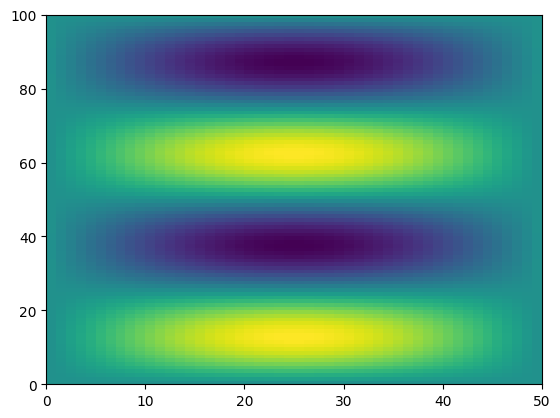

In [88]:
f_transposed = f.transpose()
plt.pcolormesh(f_transposed)

We can also manually change the shape of an array... as long as the new shape has the same number of elements.

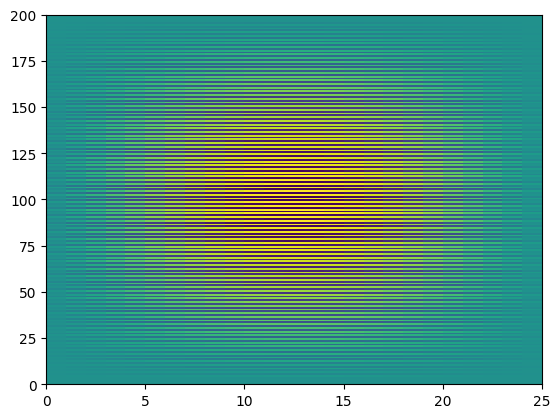

In [89]:
g = np.reshape(f, (200, 25))
plt.pcolormesh(g)

We can also "tile" an array to repeat it many times.

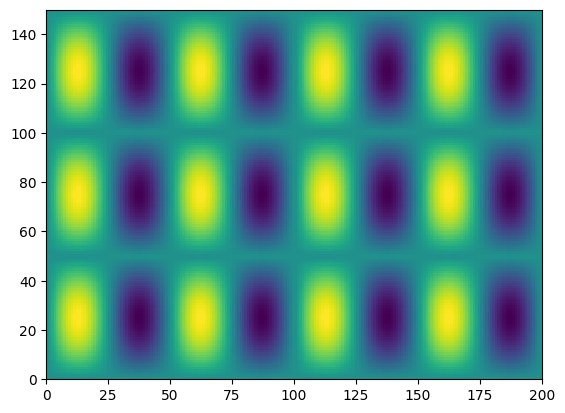

In [90]:
f_tiled = np.tile(f, (3, 2))
plt.pcolormesh(f_tiled)

Another common need is to add an extra dimension to an array. This can be done by indexing with `None`.

In [91]:
x.shape

(100,)

In [92]:
x[None, :].shape

(1, 100)

In [93]:
x[None, :, None, None].shape

(1, 100, 1, 1)

> **Try it.** Take the 2D array `f`. Transpose it and print the shape. Then reshape it to `(10, 500)` and print the shape. Finally, add a new leading axis so the shape becomes `(1, 50, 100)` — verify with `.shape`.

**Try it — my attempt**

In [94]:
print("original:  ", f.shape)              # (50, 100)
print("transposed:", f.transpose().shape)  # (100, 50)

f_reshaped = np.reshape(f, (10, 500))
print("reshaped:  ", f_reshaped.shape)     # (10, 500)

f_newaxis = f[None, :, :]
print("new axis:  ", f_newaxis.shape)      # (1, 50, 100)

original:   (50, 100)
transposed: (100, 50)
reshaped:   (10, 500)
new axis:   (1, 50, 100)


## Broadcasting

Not all arrays we want to work with have the same size. *Broadcasting* is an efficient way to combine arrays of different sizes. The core concept is telling NumPy which dimensions are supposed to line up.

**General rules:** NumPy compares shapes element-wise starting from the trailing dimensions (right to left):

- If the dimensions are equal, they're compatible.
- If one of the dimensions is 1, it's "stretched" to match the other.
- If the dimensions are unequal and neither is 1, the arrays are not broadcastable.

In [95]:
print(f.shape, x.shape)
g = f * x
print(g.shape)

(50, 100) (100,)
(50, 100)


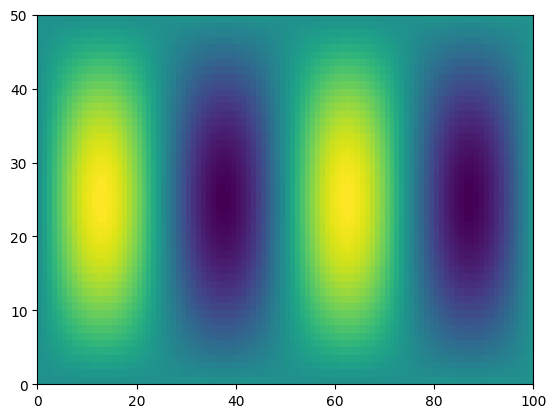

In [96]:
plt.pcolormesh(f)

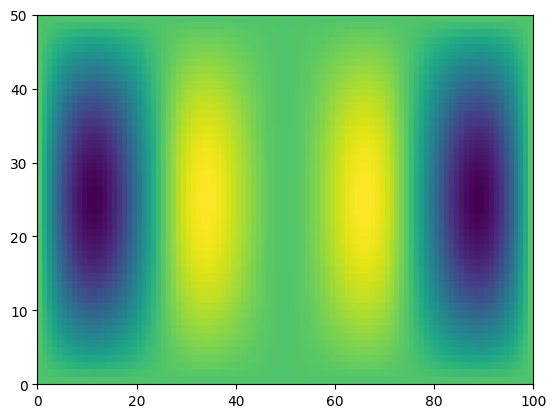

In [97]:
plt.pcolormesh(g)

However, if the last two dimensions are *not* the same, NumPy cannot just automatically figure it out.

In [98]:
print(f.shape, y.shape)
# This raises a ValueError because (50, 100) and (50,) don't align on the trailing axis.
try:
    h = f * y
except ValueError as e:
    print("ValueError:", e)

(50, 100) (50,)
ValueError: operands could not be broadcast together with shapes (50,100) (50,) 


We can help NumPy by adding an extra dimension to `y` at the end. Then the length-50 dimensions line up.

In [99]:
print(f.shape, y[:, None].shape)
h = f * y[:, None]
print(h.shape)

(50, 100) (50, 1)
(50, 100)


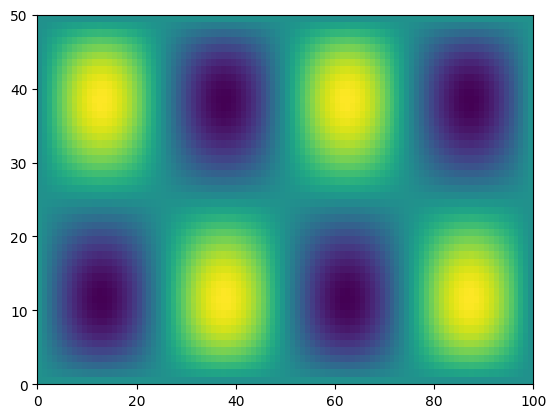

In [100]:
plt.pcolormesh(h)

> **Try it.** Create and plot `f = np.sin(xx) * np.cos(0.5*yy)` from before — but use the **1D** `x` and `y` arrays plus broadcasting (add a `None` axis on each in the right place). Verify your result looks the same as the 2D version above.

**Try it — my attempt**

broadcast shape: (50, 100)


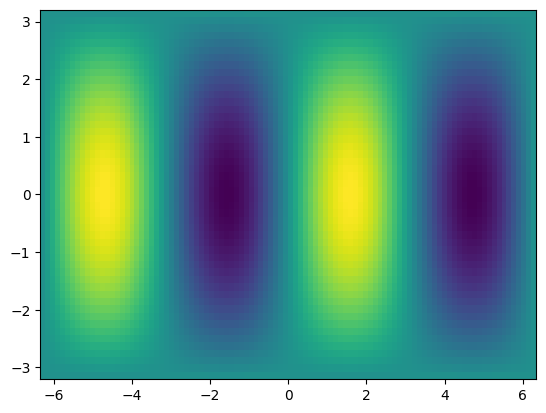

matches 2D version: True


In [101]:
# x is (100,) along columns, y is (50,) along rows. We want a (50, 100) result.
# y -> (50, 1) broadcasts down the rows; x -> (1, 100) broadcasts across the columns.
f_bcast = np.sin(x[None, :]) * np.cos(0.5 * y[:, None])
print("broadcast shape:", f_bcast.shape)   # (50, 100)

plt.pcolormesh(xx, yy, f_bcast)
plt.show()

# Confirm it matches the 2D meshgrid version
print("matches 2D version:", np.allclose(f_bcast, np.sin(xx) * np.cos(0.5 * yy)))

## Reduction Operations

In scientific data analysis we usually start with a lot of data and want to reduce it down to make plots or summary tables. Operations that reduce the size of arrays are called "reductions". The usual statistical reductions — sum, mean, standard deviation — work as you'd expect on the whole array:

In [102]:
print(g.sum())
print(g.mean())
print(g.std())

-3083.038387807155
-0.616607677561431
1.6402280119141424


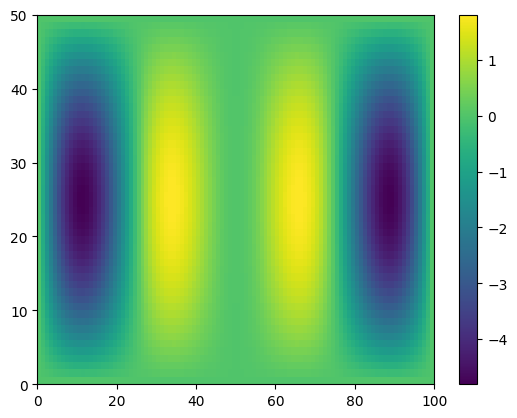

In [103]:
plt.pcolormesh(g)
plt.colorbar()

We can reduce along **specific axes**. `axis=0` reduces along the first dimension (rows of `g`), leaving the column means. `axis=1` reduces along the second dimension, leaving the row means.

In [104]:
g_ymean = g.mean(axis=0)
g_xmean = g.mean(axis=1)

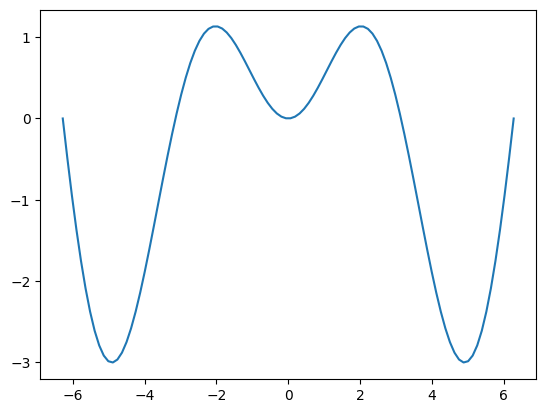

In [105]:
plt.plot(x, g_ymean)

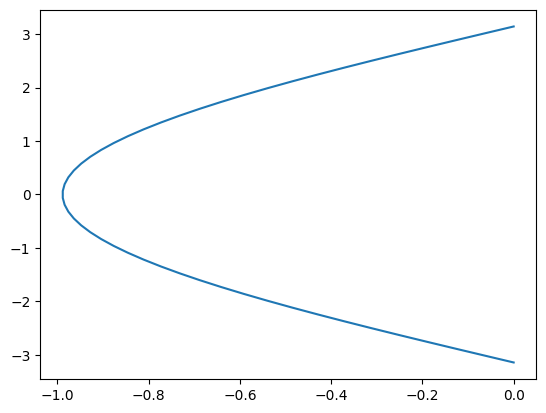

In [106]:
plt.plot(g_xmean, y)

Reductions can also operate on **multiple axes at once** — useful for higher-dimensional data.

In [107]:
arr3d = np.ones((100, 50, 25))
arr3d.mean(axis=(0, 1, 2))   # reduce across all three axes

np.float64(1.0)

> **Try it.** Take `g`. Compute its overall sum, mean, and standard deviation. Then take the mean **along axis 0** (the column means) and plot it against `x`. Take the standard deviation **along axis 1** (the row stds) and plot it against `y`.

**Try it — my attempt**

sum:  -3083.038387807155
mean: -0.616607677561431
std:  1.6402280119141424


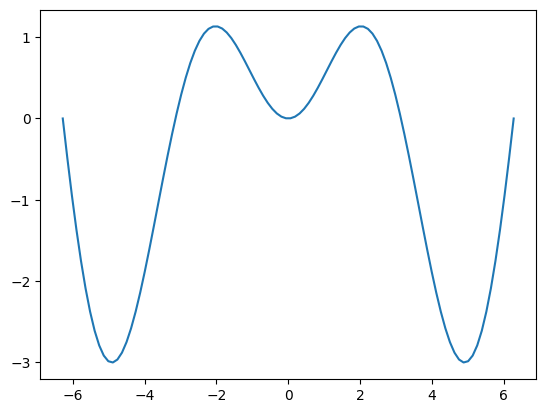

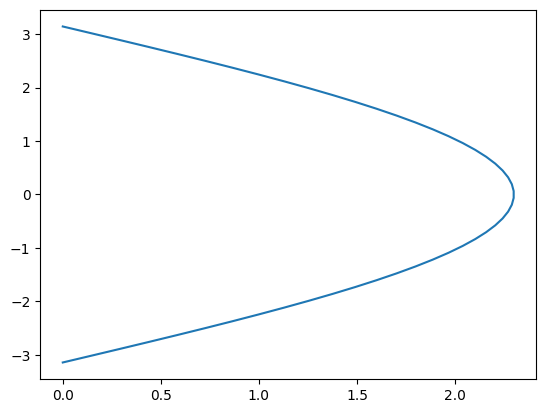

In [108]:
print("sum: ", g.sum())
print("mean:", g.mean())
print("std: ", g.std())

# Mean along axis 0 -> column means -> length 100 -> plot against x
g_col_mean = g.mean(axis=0)
plt.plot(x, g_col_mean)
plt.show()

# Std along axis 1 -> row stds -> length 50 -> plot against y
g_row_std = g.std(axis=1)
plt.plot(g_row_std, y)
plt.show()

## Data Files

It's often useful to save a numpy array to disk so you can reload it later or share it. NumPy provides a simple `.npy` binary format for this, plus loaders for plain text and other common formats.

In [109]:
np.save('g.npy', g)

> **Warning.** NumPy `.npy` files are convenient for temporary data, but are not a robust archival format. Later we'll meet NetCDF, the recommended format for earth and environmental data.

In [110]:
g_loaded = np.load('g.npy')
g_loaded

array([[-9.42326863e-32, -4.77205105e-17, -9.27211559e-17, ...,
        -9.27211559e-17, -4.77205105e-17, -9.42326863e-32],
       [-9.86000036e-17, -4.99321700e-02, -9.70184196e-02, ...,
        -9.70184196e-02, -4.99321700e-02, -9.86000036e-17],
       [-1.96794839e-16, -9.96591580e-02, -1.93638170e-01, ...,
        -1.93638170e-01, -9.96591580e-02, -1.96794839e-16],
       ...,
       [-1.96794839e-16, -9.96591580e-02, -1.93638170e-01, ...,
        -1.93638170e-01, -9.96591580e-02, -1.96794839e-16],
       [-9.86000036e-17, -4.99321700e-02, -9.70184196e-02, ...,
        -9.70184196e-02, -4.99321700e-02, -9.86000036e-17],
       [-9.42326863e-32, -4.77205105e-17, -9.27211559e-17, ...,
        -9.27211559e-17, -4.77205105e-17, -9.42326863e-32]])

We can confirm the round-trip worked with `np.testing.assert_equal`. No output means the assertion **passed** — the loaded array is element-wise equal to the original.

In [111]:
np.testing.assert_equal(g, g_loaded)

> **Try it.** Save the 3D array `arr3d` to a file called `arr3d.npy`. Load it back into a new variable and verify they're equal using `np.testing.assert_equal`.

**Try it — my attempt**

In [112]:
np.save('arr3d.npy', arr3d)
arr3d_loaded = np.load('arr3d.npy')
np.testing.assert_equal(arr3d, arr3d_loaded)
print("arr3d round-trip OK — arrays are equal.")

arr3d round-trip OK — arrays are equal.


## Recap

We created arrays (`np.array`, `zeros`/`ones`/`full`, `arange`/`linspace`, `meshgrid`), inspected `shape` and `dtype`, indexed and sliced them (including boolean masks), and visualized 1D and 2D data with `plt.plot` and `plt.pcolormesh`. We did element-wise math, reshaped/transposed/tiled arrays, used broadcasting (with `None` axes) to combine different-shaped arrays, reduced arrays with `sum`/`mean`/`std` along chosen axes, and saved/loaded arrays with `np.save`/`np.load`.